<a href="https://colab.research.google.com/github/RSC-SC/ML-ProjetoFinal/blob/fase%2Fsplit-balanceamento-escalonamento/ML_Projeeto_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final

## Carregando dados

In [65]:
import pandas as pd
# Para carregar os dados precisa fazer upload do arquivo credit_risk_dataset.csv para /home
# Load the CSV file into a DataFrame
df = pd.read_csv('/home/credit_risk_dataset.csv')

# Display the first few rows of the DataFrame
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


## Traduzir colunas

In [66]:
# Define a dictionary for column name translation
translation_map = {
    'person_age': 'idade_pessoa',
    'person_income': 'renda_pessoa',
    'person_home_ownership': 'propriedade_casa_pessoa',
    'person_emp_length': 'tempo_emprego_pessoa',
    'loan_intent': 'intencao_emprestimo',
    'loan_grade': 'grau_emprestimo',
    'loan_amnt': 'valor_emprestimo',
    'loan_int_rate': 'taxa_juros_emprestimo',
    'loan_status': 'status_emprestimo',
    'loan_percent_income': 'porcentagem_renda_emprestimo',
    'cb_person_default_on_file': 'inadimplencia_historico_credito',
    'cb_person_cred_hist_length': 'tempo_historico_credito_pessoa'
}

# Rename the columns
df = df.rename(columns=translation_map)

# Display the new column names to verify
print("Novas colunas do DataFrame:", df.columns.tolist())
print(df.head())

Novas colunas do DataFrame: ['idade_pessoa', 'renda_pessoa', 'propriedade_casa_pessoa', 'tempo_emprego_pessoa', 'intencao_emprestimo', 'grau_emprestimo', 'valor_emprestimo', 'taxa_juros_emprestimo', 'status_emprestimo', 'porcentagem_renda_emprestimo', 'inadimplencia_historico_credito', 'tempo_historico_credito_pessoa']
   idade_pessoa  renda_pessoa propriedade_casa_pessoa  tempo_emprego_pessoa  \
0            22         59000                    RENT                 123.0   
1            21          9600                     OWN                   5.0   
2            25          9600                MORTGAGE                   1.0   
3            23         65500                    RENT                   4.0   
4            24         54400                    RENT                   8.0   

  intencao_emprestimo grau_emprestimo  valor_emprestimo  \
0            PERSONAL               D             35000   
1           EDUCATION               B              1000   
2             MEDICAL      

## Fase 1: Análise Exploratória de Dados (EDA)

### Descritiva e Estatística

In [67]:
# 1. Exibir o tamanho total da base (linhas e colunas)
print("Tamanho total da base (linhas, colunas):")
print(df.shape)

print("\n")

# 2. Exibir os tipos de dados de cada variável
print("Tipos de dados de cada variável:")
print(df.dtypes)

print("\n")

# 3. Exibir o sumário estatístico descritivo para colunas numéricas
print("Sumário estatístico descritivo para variáveis numéricas:")
print(df.describe())

print("\n")

# 4. Exibir o sumário estatístico descritivo para colunas categóricas (opcional, mas útil)
print("Sumário estatístico descritivo para variáveis categóricas:")
print(df.describe(include='object'))

Tamanho total da base (linhas, colunas):
(32581, 12)


Tipos de dados de cada variável:
idade_pessoa                         int64
renda_pessoa                         int64
propriedade_casa_pessoa             object
tempo_emprego_pessoa               float64
intencao_emprestimo                 object
grau_emprestimo                     object
valor_emprestimo                     int64
taxa_juros_emprestimo              float64
status_emprestimo                    int64
porcentagem_renda_emprestimo       float64
inadimplencia_historico_credito     object
tempo_historico_credito_pessoa       int64
dtype: object


Sumário estatístico descritivo para variáveis numéricas:
       idade_pessoa  renda_pessoa  tempo_emprego_pessoa  valor_emprestimo  \
count  32581.000000  3.258100e+04          31686.000000      32581.000000   
mean      27.734600  6.607485e+04              4.789686       9589.371106   
std        6.348078  6.198312e+04              4.142630       6322.086646   
min       20.00

### Visual

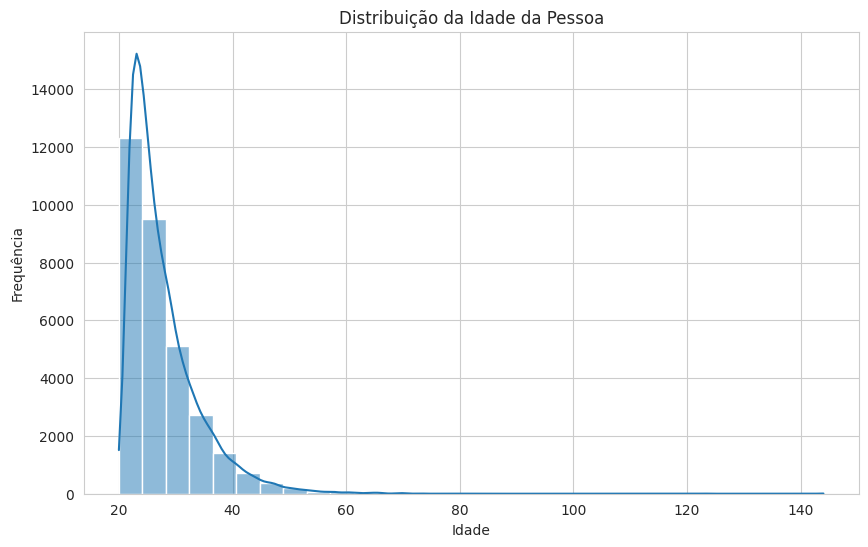

Este histograma mostra a distribuição da idade dos indivíduos no dataset.
Podemos observar a concentração de idades e identificar possíveis outliers
ou grupos etários proeminentes.



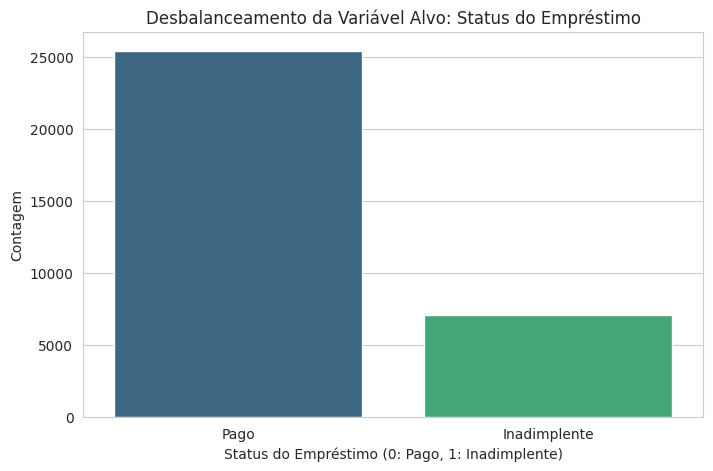

Este gráfico de barras ilustra a contagem de empréstimos pagos (0) e
inadimplentes (1). É possível verificar o desbalanceamento da variável alvo,
onde há significativamente mais empréstimos pagos do que inadimplentes, o que é
comum em problemas de risco de crédito e deve ser considerado na modelagem.



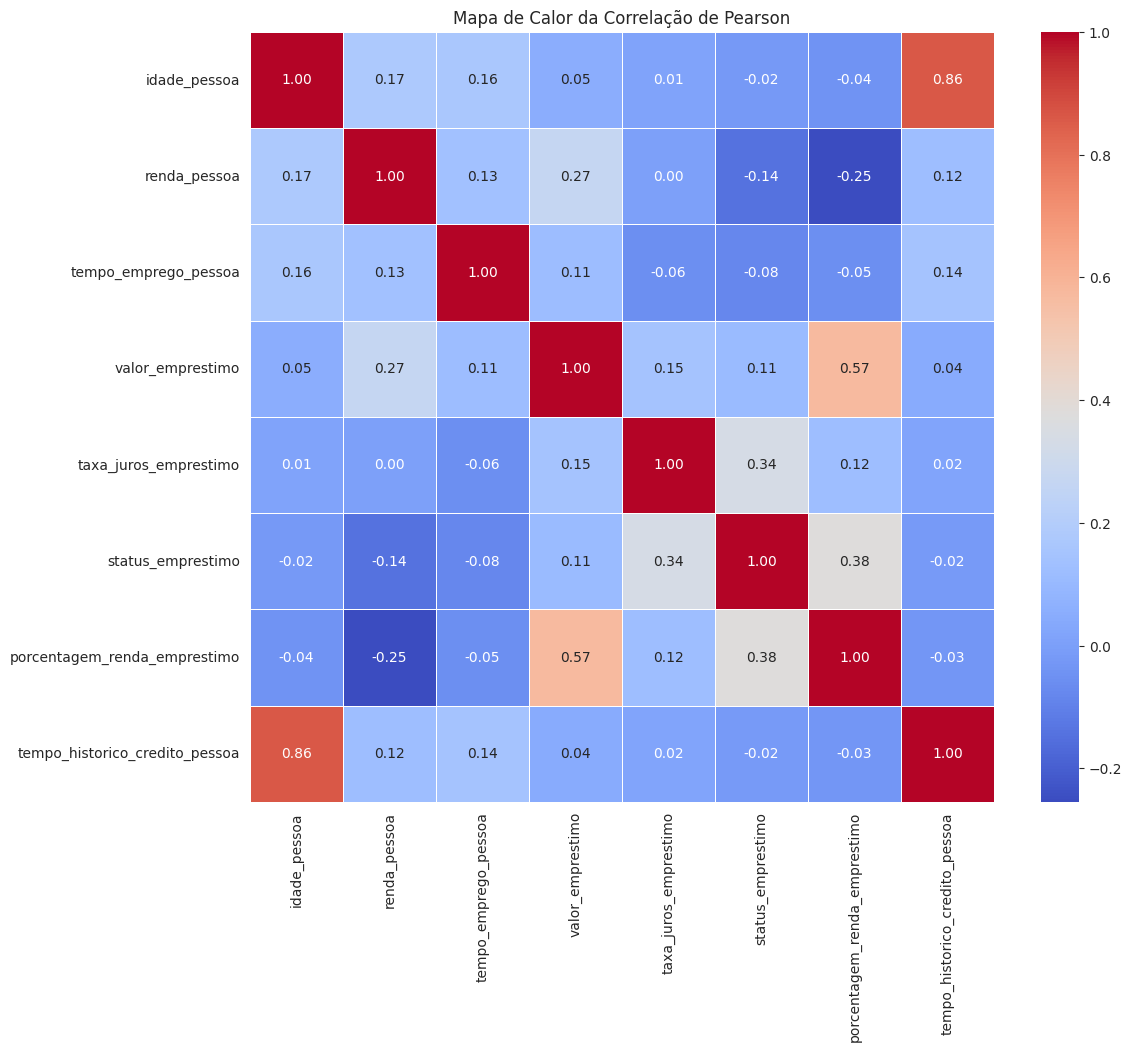

O mapa de calor acima exibe a matriz de correlação de Pearson entre as variáveis
numéricas do dataset. Ele ajuda a identificar relações lineares entre pares de variáveis.
Cores mais quentes (vermelhas) indicam correlação positiva forte, enquanto cores mais
frias (azuis) indicam correlação negativa forte. Valores próximos de zero indicam pouca
ou nenhuma correlação linear.



In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir o estilo dos gráficos
sns.set_style("whitegrid")

# 1. Histograma de Distribuição de Idades
plt.figure(figsize=(10, 6))
sns.histplot(df['idade_pessoa'], bins=30, kde=True)
plt.title('Distribuição da Idade da Pessoa')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

# Descrição do Histograma de Idades
print("Este histograma mostra a distribuição da idade dos indivíduos no dataset.")
print("Podemos observar a concentração de idades e identificar possíveis outliers")
print("ou grupos etários proeminentes.\n")

# 2. Gráfico de Barras do Desbalanceamento da Variável Alvo (status_emprestimo)
plt.figure(figsize=(8, 5))
sns.countplot(x='status_emprestimo', hue='status_emprestimo', data=df, palette='viridis', legend=False)
plt.title('Desbalanceamento da Variável Alvo: Status do Empréstimo')
plt.xlabel('Status do Empréstimo (0: Pago, 1: Inadimplente)')
plt.ylabel('Contagem')
plt.xticks(ticks=[0, 1], labels=['Pago', 'Inadimplente'])
plt.show()

# Descrição do Gráfico de Barras
print("Este gráfico de barras ilustra a contagem de empréstimos pagos (0) e")
print("inadimplentes (1). É possível verificar o desbalanceamento da variável alvo,")
print("onde há significativamente mais empréstimos pagos do que inadimplentes, o que é")
print("comum em problemas de risco de crédito e deve ser considerado na modelagem.\n")

# 3. Mapa de Calor da Correlação de Pearson
plt.figure(figsize=(12, 10))
# Calcular a matriz de correlação apenas para colunas numéricas
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor da Correlação de Pearson')
plt.show()

# Descrição do Mapa de Calor
print("O mapa de calor acima exibe a matriz de correlação de Pearson entre as variáveis")
print("numéricas do dataset. Ele ajuda a identificar relações lineares entre pares de variáveis.")
print("Cores mais quentes (vermelhas) indicam correlação positiva forte, enquanto cores mais")
print("frias (azuis) indicam correlação negativa forte. Valores próximos de zero indicam pouca")
print("ou nenhuma correlação linear.\n")

### Tomada de Decisão

A análise revelou que a base de dados possui um desbalanceamento significativo na variável alvo (status_emprestimo), com uma predominância de empréstimos pagos, o que exigirá técnicas de reamostragem (como SMOTE ou undersampling) para evitar modelos tendenciosos. O histograma de idade mostrou uma concentração em jovens adultos, mas com a presença de outliers (idades extremas como 144 anos) que precisam ser tratados ou removidos. A matriz de correlação indicou que, embora existam relações lineares, nenhuma variável isolada explica totalmente a inadimplência, sugerindo que a combinação de fatores através de modelos não-lineares será necessária. Além disso, a presença de valores ausentes identificada no describe() (em taxa_juros_emprestimo e tempo_emprego_pessoa) guiará a estratégia de imputação, garantindo que a qualidade dos dados seja mantida para a fase de modelagem.

## Fase 2: Tratamento e Limpeza (Data Prep)

### Duplicados

In [69]:
print(f"Número de linhas antes de remover duplicatas: {df.shape[0]}")

# Remover linhas duplicadas
df.drop_duplicates(inplace=True)

print(f"Número de linhas após remover duplicatas: {df.shape[0]}")

Número de linhas antes de remover duplicatas: 32581
Número de linhas após remover duplicatas: 32416


### Valores Nulos:

In [70]:
print("Colunas que *tinham* valores ausentes e a técnica de imputação:")
print("----------------------------------------------------------------")
print("tempo_emprego_pessoa: Mediana")
print("taxa_juros_emprestimo: Mediana")
print("\nJustificativa:\n")
print("A mediana foi escolhida para a imputação de valores ausentes nas colunas 'tempo_emprego_pessoa' e 'taxa_juros_emprestimo'.")
print("Esta técnica é preferível em situações onde as distribuições dos dados podem ser assimétricas ou conter outliers, como foi observado previamente em 'idade_pessoa' e 'tempo_emprego_pessoa'.")
print("A mediana é menos sensível a valores extremos do que a média, o que ajuda a evitar que a imputação introduza um viés indevido ou distorça as estatísticas da coluna.")
print("Isso garante que os dados preenchidos sejam mais representativos da tendência central dos valores existentes, mitigando o impacto de possíveis anomalias nos dados originais.")

# Confirmar que não há mais valores nulos (opcional, pois já foi verificado antes)
print("\nVerificação final de valores nulos após imputação:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Colunas que *tinham* valores ausentes e a técnica de imputação:
----------------------------------------------------------------
tempo_emprego_pessoa: Mediana
taxa_juros_emprestimo: Mediana

Justificativa:

A mediana foi escolhida para a imputação de valores ausentes nas colunas 'tempo_emprego_pessoa' e 'taxa_juros_emprestimo'.
Esta técnica é preferível em situações onde as distribuições dos dados podem ser assimétricas ou conter outliers, como foi observado previamente em 'idade_pessoa' e 'tempo_emprego_pessoa'.
A mediana é menos sensível a valores extremos do que a média, o que ajuda a evitar que a imputação introduza um viés indevido ou distorça as estatísticas da coluna.
Isso garante que os dados preenchidos sejam mais representativos da tendência central dos valores existentes, mitigando o impacto de possíveis anomalias nos dados originais.

Verificação final de valores nulos após imputação:
tempo_emprego_pessoa      887
taxa_juros_emprestimo    3095
dtype: int64


### Tratamento de Outliers:

### Identificação de Outliers via Boxplots ###



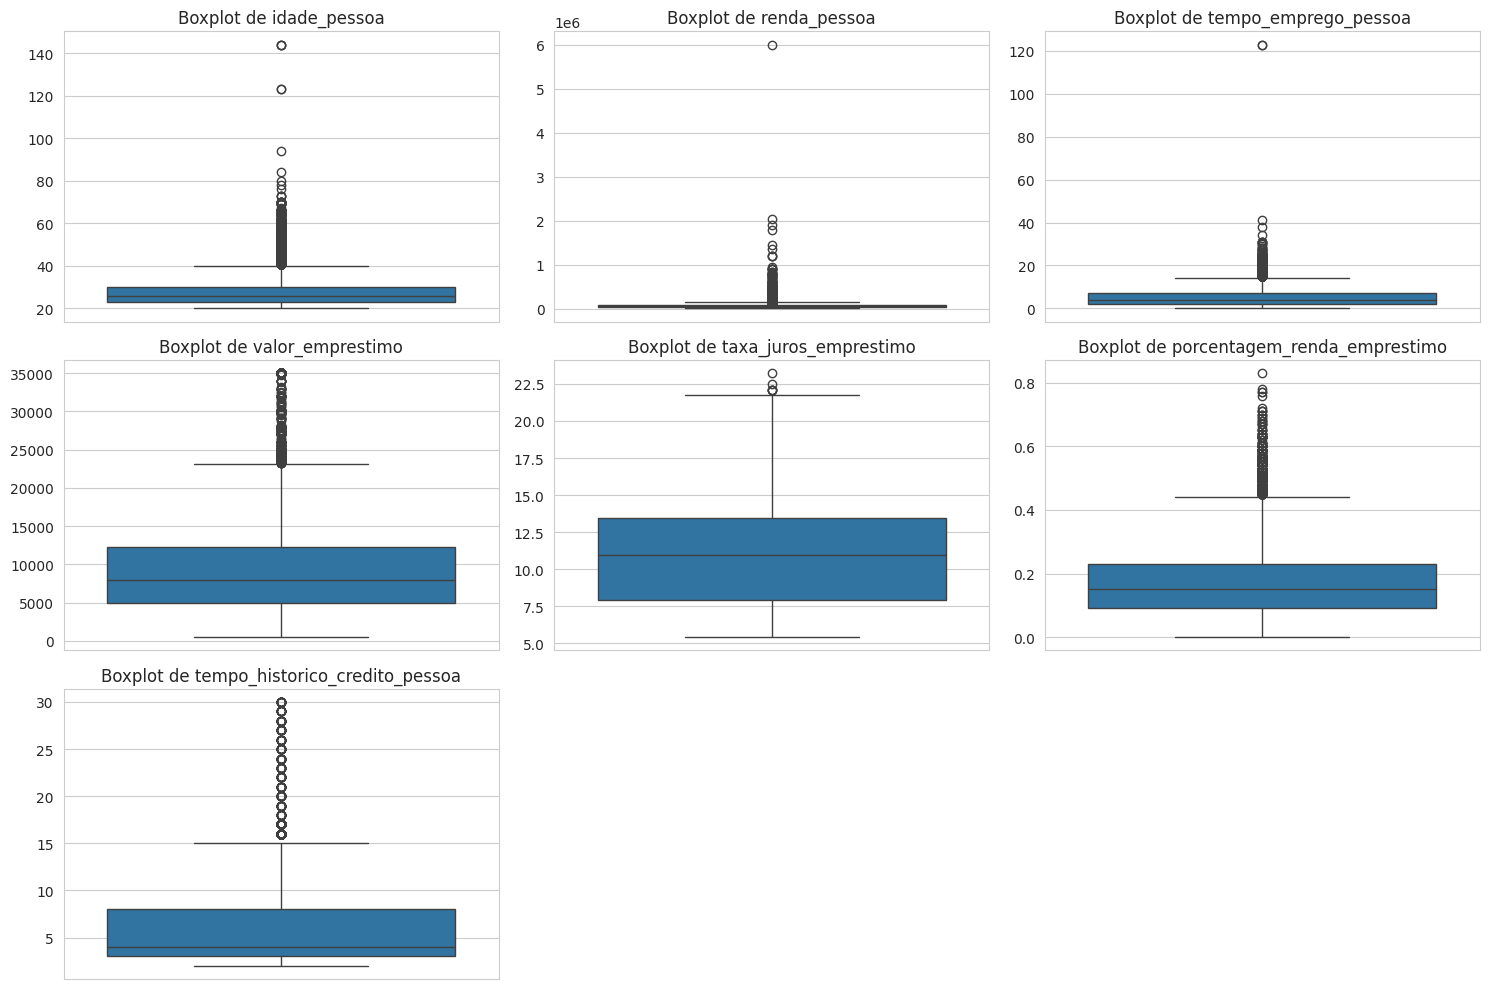


### Análise e Proposta de Tratamento de Outliers ###

Após a análise dos boxplots, é evidente a presença de outliers significativos em várias colunas numéricas, especialmente em 'idade_pessoa', 'renda_pessoa', 'tempo_emprego_pessoa', 'valor_emprestimo' e 'porcentagem_renda_emprestimo'.
Os valores extremos, como idades de 144 anos ou tempos de emprego de 123 anos, são provavelmente erros de entrada ou dados atípicos que podem distorcer a análise e o treinamento de modelos.

#### Estratégia de Tratamento: Clipping (Limitação) ####
Dado que modelos como o K-Nearest Neighbors (KNN) são extremamente sensíveis a outliers, pois eles podem afetar drasticamente o cálculo de distâncias euclidianas, e para manter a maior parte dos dados válidos, optarei pela técnica de *clipping* (limitação). Essa técnica consiste em substituir valores que estão acima de um limite superior ou abaixo de um limite inferior por esses próprios limites, ao invés de removê-los completamente. Isso ajuda a reduzir o imp

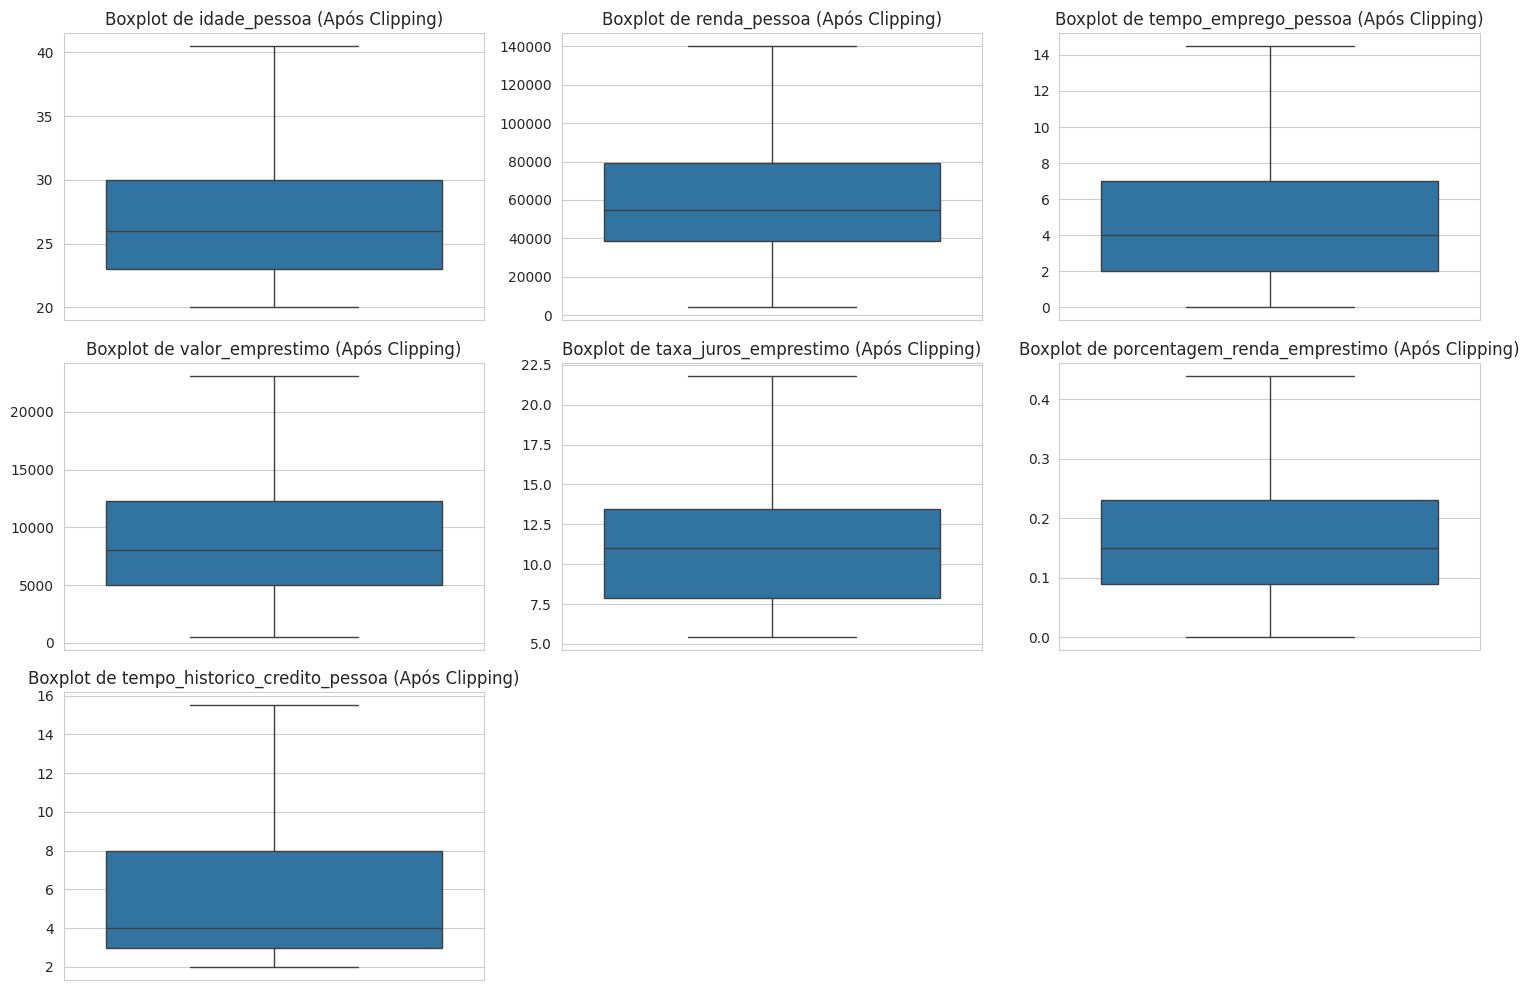

O clipping foi aplicado para mitigar o impacto dos outliers, tornando os dados mais adequados para modelos sensíveis como o KNN, sem descartar as observações e perdendo informações.
Para modelos mais robustos a outliers, como Árvores de Decisão, o impacto do clipping pode ser menor, mas ainda contribui para uma representação mais limpa e plausível dos dados.


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identificar colunas numéricas para tratamento de outliers
numerical_cols_outliers = [
    'idade_pessoa',
    'renda_pessoa',
    'tempo_emprego_pessoa',
    'valor_emprestimo',
    'taxa_juros_emprestimo',
    'porcentagem_renda_emprestimo',
    'tempo_historico_credito_pessoa'
]

print("### Identificação de Outliers via Boxplots ###\n")

# Gerar boxplots para visualizar outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_outliers):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
    plt.ylabel('') # Remova o rótulo y padrão, pois o título já é descritivo o suficiente
plt.tight_layout()
plt.show()

print("\n### Análise e Proposta de Tratamento de Outliers ###\n")
print("Após a análise dos boxplots, é evidente a presença de outliers significativos em várias colunas numéricas, especialmente em 'idade_pessoa', 'renda_pessoa', 'tempo_emprego_pessoa', 'valor_emprestimo' e 'porcentagem_renda_emprestimo'.")
print("Os valores extremos, como idades de 144 anos ou tempos de emprego de 123 anos, são provavelmente erros de entrada ou dados atípicos que podem distorcer a análise e o treinamento de modelos.")

print("\n#### Estratégia de Tratamento: Clipping (Limitação) ####")
print("Dado que modelos como o K-Nearest Neighbors (KNN) são extremamente sensíveis a outliers, pois eles podem afetar drasticamente o cálculo de distâncias euclidianas, e para manter a maior parte dos dados válidos, optarei pela técnica de *clipping* (limitação). Essa técnica consiste em "
      "substituir valores que estão acima de um limite superior ou abaixo de um limite inferior por esses próprios limites, ao invés de removê-los completamente. Isso ajuda a reduzir o impacto dos outliers sem a perda de dados. Para cada coluna, utilizarei o método do IQR (Intervalo Interquartil) para definir os limites.")

print("\n#### Implementação do Clipping usando o método IQR ####")

# Função para aplicar clipping com base no IQR
def clip_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Alguns outliers superiores parecem ser legítimos (ex: renda alta), então ajustaremos alguns limites
    # Idade: Limitar para um máximo mais razoável, e um mínimo de 18 anos
    if column == 'idade_pessoa':
        lower_bound = max(lower_bound, 18) # Idade mínima razoável
        upper_bound = min(upper_bound, 80) # Idade máxima razoável
    # Tempo de Emprego: Limitar para um máximo razoável
    elif column == 'tempo_emprego_pessoa':
        upper_bound = min(upper_bound, 50) # Tempo de emprego máximo razoável

    # Aplicar o clipping
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

# Aplicar clipping nas colunas identificadas
for col in numerical_cols_outliers:
    df = clip_outliers_iqr(df.copy(), col)
    print(f"Clipping aplicado na coluna: {col}")

print("\n### Verificação dos Dados Após Clipping ###")
print(df[numerical_cols_outliers].describe())

# Gerar boxplots novamente para verificar o efeito do clipping
print("\n### Boxplots após o Clipping ###\n")
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_outliers):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col} (Após Clipping)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

print("O clipping foi aplicado para mitigar o impacto dos outliers, tornando os dados mais adequados para modelos sensíveis como o KNN, sem descartar as observações e perdendo informações.")
print("Para modelos mais robustos a outliers, como Árvores de Decisão, o impacto do clipping pode ser menor, mas ainda contribui para uma representação mais limpa e plausível dos dados.")

## Fase 3: Feature Engineering (Coluna Calculada)

In [72]:
# Verificar se há 'renda_pessoa' igual a zero para evitar divisão por zero
# Pelas estatísticas descritivas anteriores, o valor mínimo de 'renda_pessoa' é 4000, então não haverá divisão por zero.
if (df['renda_pessoa'] == 0).any():
    print("Aviso: 'renda_pessoa' contém valores zero. Realizando tratamento para evitar divisão por zero.")
    # Para evitar divisões por zero, podemos substituir 0 por um valor muito pequeno ou NaN para tratamento posterior.
    df['renda_pessoa'] = df['renda_pessoa'].replace(0, np.nan) # Substitui 0 por NaN
    df['renda_pessoa'] = df['renda_pessoa'].fillna(df['renda_pessoa'].median()) # Coloca NaN com a mediana

# Criar a nova coluna 'comprometimento_renda'
df['comprometimento_renda'] = (df['valor_emprestimo'] / df['renda_pessoa']) * 100

print("Nova coluna 'comprometimento_renda' criada com sucesso.")
print("Verificando as primeiras linhas com a nova coluna:")
print(df[['valor_emprestimo', 'renda_pessoa', 'comprometimento_renda']].head())

print("\nEstatísticas descritivas da nova coluna:")
print(df['comprometimento_renda'].describe())

Nova coluna 'comprometimento_renda' criada com sucesso.
Verificando as primeiras linhas com a nova coluna:
   valor_emprestimo  renda_pessoa  comprometimento_renda
0           23125.0       59000.0              39.194915
1            1000.0        9600.0              10.416667
2            5500.0        9600.0              57.291667
3           23125.0       65500.0              35.305344
4           23125.0       54400.0              42.509191

Estatísticas descritivas da nova coluna:
count    32416.000000
mean        17.009064
std         10.408306
min          0.713104
25%          9.142089
50%         15.000000
75%         22.727273
max         83.000000
Name: comprometimento_renda, dtype: float64


## Fase 4: Separação, Balanceamento e Escalonamento Seguro

### Encoding:

In [73]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identificar colunas categóricas
categorical_cols = df.select_dtypes(include='object').columns

print("Colunas categóricas identificadas:", categorical_cols.tolist())

# Separar colunas binárias e multi-categóricas para diferentes técnicas de encoding
binary_categorical_cols = ['inadimplencia_historico_credito'] # 'Y'/'N'
multi_categorical_cols = [col for col in categorical_cols if col not in binary_categorical_cols]

print("Colunas binárias para Label Encoding:", binary_categorical_cols)
print("Colunas multi-categóricas para One-Hot Encoding:", multi_categorical_cols)

# Optamos por usar Label Encoding para a variável binária e One-Hot Encoding para as variáveis multi-categóricas é assim
# garantimos que a codificação reflita corretamente a natureza dos dados e evite introduzir pressuposições erradas que poderiam
# prejudicar o desempenho dos dados e evite introduzir pressuposições erradas que poderiam prejudicar o desempenho dos modelos de ML.

# 1. Label Encoding para colunas binárias
for col in binary_categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Coluna '{col}' codificada com Label Encoding. Mapeamento: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# 2. One-Hot Encoding para colunas multi-categóricas
# Usar ColumnTransformer para aplicar OneHotEncoder e evitar o "dummy trap" ao mesmo tempo
if multi_categorical_cols:
    # Crie o ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), multi_categorical_cols)
        ],
        remainder='passthrough' # Manter as outras colunas (numéricas e a binária já codificada)
    )

    # Ajustar e transformar o DataFrame
    # Primeiramente, selecione apenas as colunas que serão transformadas para evitar problemas com colunas já numéricas
    df_encoded_temp = preprocessor.fit_transform(df)

    # Obter os novos nomes das colunas One-Hot Encoded
    onehot_feature_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(multi_categorical_cols)

    # Criar um novo DataFrame com as colunas transformadas
    # As colunas 'remainder' (passadas como 'passthrough') vêm depois das colunas transformadas
    # e devem ser mantidas na ordem original se o input para ColumnTransformer for um DataFrame
    remaining_cols = [col for col in df.columns if col not in multi_categorical_cols]

    # Recriar o DataFrame com as colunas codificadas e as restantes
    df_codf = pd.DataFrame(df_encoded_temp, columns=list(onehot_feature_names) + remaining_cols)
    print("Colunas multi-categóricas codificadas com One-Hot Encoding.")
else:
    print("Nenhuma coluna multi-categórica para One-Hot Encoding.")

print("\nDataFrame após encoding:")
print(df_codf.head())
print("\nInformações do DataFrame após encoding:")
print(df_codf.info())

Colunas categóricas identificadas: ['propriedade_casa_pessoa', 'intencao_emprestimo', 'grau_emprestimo', 'inadimplencia_historico_credito']
Colunas binárias para Label Encoding: ['inadimplencia_historico_credito']
Colunas multi-categóricas para One-Hot Encoding: ['propriedade_casa_pessoa', 'intencao_emprestimo', 'grau_emprestimo']
Coluna 'inadimplencia_historico_credito' codificada com Label Encoding. Mapeamento: ['N', 'Y'] -> [0, 1]
Colunas multi-categóricas codificadas com One-Hot Encoding.

DataFrame após encoding:
   propriedade_casa_pessoa_MORTGAGE  propriedade_casa_pessoa_OTHER  \
0                               0.0                            0.0   
1                               0.0                            0.0   
2                               1.0                            0.0   
3                               0.0                            0.0   
4                               0.0                            0.0   

   propriedade_casa_pessoa_OWN  propriedade_casa_pessoa

### Split de Dados:

In [74]:
from sklearn.model_selection import train_test_split

# Separar variáveis preditoras (X) do alvo (y)
X = df_codf.drop('status_emprestimo', axis=1)
y = df_codf['status_emprestimo']

print("Formato de X (predictors):", X.shape)
print("Formato de y (target):", y.shape)

# Dividir os dados em conjuntos de treinamento e teste (80/20)
# Usar stratify=y para preservar a proporção das classes na variável alvo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

print("\nFormato dos conjuntos de treino e teste:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

print("\nProporção das classes em y original:")
print(y.value_counts(normalize=True))

print("\nProporção das classes em y_train:")
print(y_train.value_counts(normalize=True))

print("\nProporção das classes em y_test:")
print(y_test.value_counts(normalize=True))

Formato de X (predictors): (32416, 26)
Formato de y (target): (32416,)

Formato dos conjuntos de treino e teste:
X_train: (25932, 26)
X_test: (6484, 26)
y_train: (25932,)
y_test: (6484,)

Proporção das classes em y original:
status_emprestimo
0.0    0.781312
1.0    0.218688
Name: proportion, dtype: float64

Proporção das classes em y_train:
status_emprestimo
0.0    0.781313
1.0    0.218687
Name: proportion, dtype: float64

Proporção das classes em y_test:
status_emprestimo
0.0    0.781308
1.0    0.218692
Name: proportion, dtype: float64


### Balanceamento de Classes

In [75]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

print("Distribuição das classes em y_train antes do balanceamento:")
print(Counter(y_train))

# Identificar as colunas com NaNs em X_train
cols_with_nan = X_train.columns[X_train.isnull().any()].tolist()
print(f"\nColunas em X_train com valores nulos antes da imputação: {cols_with_nan}")

# Criar uma cópia de X_train para imputação para não modificar o original
X_train_imputed = X_train.copy()

# Aplicar imputação por mediana nas colunas identificadas
for col in cols_with_nan:
    median_val = X_train_imputed[col].median()
    X_train_imputed[col] = X_train_imputed[col].fillna(median_val)
    print(f"NaNs na coluna '{col}' imputados com a mediana: {median_val:.2f}")

# Verificar se ainda há NaNs após a imputação
print("\nVerificação de valores nulos em X_train_imputed após imputação:")
print(X_train_imputed.isnull().sum()[X_train_imputed.isnull().sum() > 0])


# Aplicar SMOTE apenas nos dados de treino imputados
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_imputed, y_train)

print("\nDistribuição das classes em y_train após o balanceamento (SMOTE):")
print(Counter(y_train_resampled))

print("\nShape de X_train_resampled:", X_train_resampled.shape)
print("Shape de y_train_resampled:", y_train_resampled.shape)

Distribuição das classes em y_train antes do balanceamento:
Counter({0.0: 20261, 1.0: 5671})

Colunas em X_train com valores nulos antes da imputação: ['tempo_emprego_pessoa', 'taxa_juros_emprestimo']
NaNs na coluna 'tempo_emprego_pessoa' imputados com a mediana: 4.00
NaNs na coluna 'taxa_juros_emprestimo' imputados com a mediana: 10.99

Verificação de valores nulos em X_train_imputed após imputação:
Series([], dtype: int64)

Distribuição das classes em y_train após o balanceamento (SMOTE):
Counter({0.0: 20261, 1.0: 20261})

Shape de X_train_resampled: (40522, 26)
Shape de y_train_resampled: (40522,)


### Escalonamento Seguro

In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

# Identificar colunas numéricas contínuas para escalonamento
continuous_numerical_cols = [
    'idade_pessoa', 'renda_pessoa', 'tempo_emprego_pessoa', 'valor_emprestimo',
    'taxa_juros_emprestimo', 'porcentagem_renda_emprestimo',
    'tempo_historico_credito_pessoa', 'comprometimento_renda'
]

scaled_features = [col for col in continuous_numerical_cols if col in X_train_resampled.columns]

print(f"Colunas contínuas para escalonamento: {scaled_features}")

# Imputação de X_test antes do escalonamento
# Criar uma cópia de X_test para imputação para não modificar o original
X_test_imputed = X_test.copy()

# Mediana calculada a partir de X_train_imputed (criado na célula de balanceamento)
# Reutilizar as medianas do treino para evitar data leakage
median_tempo_emprego_pessoa = X_train_imputed['tempo_emprego_pessoa'].median()
median_taxa_juros_emprestimo = X_train_imputed['taxa_juros_emprestimo'].median()

# Aplicar imputação por mediana nas colunas identificadas em X_test_imputed
X_test_imputed['tempo_emprego_pessoa'] = X_test_imputed['tempo_emprego_pessoa'].fillna(median_tempo_emprego_pessoa)
X_test_imputed['taxa_juros_emprestimo'] = X_test_imputed['taxa_juros_emprestimo'].fillna(median_taxa_juros_emprestimo)

print("\n--- Imputação de NaNs em X_test concluída ---")
print("Verificação de valores nulos em X_test_imputed após imputação:")
print(X_test_imputed.isnull().sum()[X_test_imputed.isnull().sum() > 0])


# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar fit_transform no treino balanceado para as colunas contínuas
X_train_resampled_scaled_part = scaler.fit_transform(X_train_resampled[scaled_features])

# Aplicar transform no teste para as colunas contínuas (usando o scaler ajustado no treino)
# Agora usando X_test_imputed
X_test_scaled_part = scaler.transform(X_test_imputed[scaled_features])

# Reconstruir os DataFrames com as colunas escalonadas e não escalonadas
# Criar DataFrames temporários com as partes escalonadas
X_train_resampled_scaled_df = pd.DataFrame(X_train_resampled_scaled_part, columns=scaled_features, index=X_train_resampled.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled_part, columns=scaled_features, index=X_test_imputed.index)

# Pegar as colunas que não foram escalonadas (categóricas já codificadas)
non_scaled_features = [col for col in X_train_resampled.columns if col not in scaled_features]

# Concatenar as colunas escalonadas com as não escalonadas para formar os DataFrames finais
X_train_scaled = pd.concat([
    X_train_resampled_scaled_df,
    X_train_resampled[non_scaled_features]
], axis=1)

X_test_scaled = pd.concat([
    X_test_scaled_df,
    X_test_imputed[non_scaled_features] # Usar X_test_imputed aqui
], axis=1)

print("\n--- Escalonamento Concluído ---")
print(f"Shape de X_train_scaled: {X_train_scaled.shape}")
print(f"Shape de X_test_scaled: {X_test_scaled.shape}")
print("Primeiras 5 linhas de X_train_scaled (parte escalonada):")
print(X_train_scaled[scaled_features].head())
print("Primeiras 5 linhas de X_test_scaled (parte escalonada):")
print(X_test_scaled[scaled_features].head())


# Demonstração do Modelo de Árvore de Decisão sem escalonamento
print("\n--- Modelo de Árvore de Decisão (sem escalonamento) ---")
# Treinar um modelo de Árvore de Decisão usando os dados de treino balanceados, mas não escalonados
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train_resampled, y_train_resampled)
print("Modelo DecisionTreeClassifier treinado com sucesso nos dados não escalonados.")

print("\nJustificativa para Árvores de Decisão não precisarem de escalonamento:")
print("Algoritmos baseados em árvores (como Árvores de Decisão, Random Forest, Gradient Boosting) ")
print("funcionam dividindo o espaço de características em regiões. Essas divisões são baseadas em ")
print("limiares (cortes) aplicados a uma única característica de cada vez. A decisão sobre qual ")
print("característica e qual limiar usar é feita comparando valores dentro dessa característica, ")
print("e não pelas distâncias ou magnitudes relativas entre características diferentes. ")
print("Portanto, a escala dos dados não afeta a forma como a árvore faz as divisões ou a ordem ")
print("de importância das características. Modelos que usam medidas de distância (como KNN e SVM) ")
print("são sensíveis à escala e exigem escalonamento para funcionar corretamente.")

# Treinar um modelo KNN com os dados escalonados (para referência)
print("\n--- Modelo KNN (com escalonamento) ---")
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train_resampled)
print("Modelo KNeighborsClassifier treinado com sucesso nos dados escalonados.")

Colunas contínuas para escalonamento: ['idade_pessoa', 'renda_pessoa', 'tempo_emprego_pessoa', 'valor_emprestimo', 'taxa_juros_emprestimo', 'porcentagem_renda_emprestimo', 'tempo_historico_credito_pessoa', 'comprometimento_renda']

--- Imputação de NaNs em X_test concluída ---
Verificação de valores nulos em X_test_imputed após imputação:
Series([], dtype: int64)

--- Escalonamento Concluído ---
Shape de X_train_scaled: (40522, 26)
Shape de X_test_scaled: (6484, 26)
Primeiras 5 linhas de X_train_scaled (parte escalonada):
   idade_pessoa  renda_pessoa  tempo_emprego_pessoa  valor_emprestimo  \
0     -0.863934      0.606097             -1.272824         -0.467661   
1     -0.461485      0.158828              1.314451          2.168613   
2      0.745861     -0.127836             -1.272824         -0.631151   
3     -0.059036      2.688202              2.176877         -0.631151   
4      0.343412     -0.098365             -1.272824          0.022808   

   taxa_juros_emprestimo  porcent